In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from utils.constants import chamber_levels

In [ ]:
# observed values, separately for hummock and hollow
obs_frac = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input', 'Tip_colonization_data_2017.csv'),
                       na_values = -9999)
obs_frac = obs_frac[['microtopography', 'species', 'plot', 'colonization_percent']]
obs_frac['colonization_percent'] /= 100.0
obs_frac['temperature'] = [chamber_levels[f'{plot:02d}'][0] for plot in obs_frac['plot']]
obs_frac['co2'] = [chamber_levels[f'{plot:02d}'][1] for plot in obs_frac['plot']]
obs_frac = obs_frac.dropna(subset = 'colonization_percent').set_index(['microtopography', 'species', 'temperature', 'co2', 'plot'])

obs_frac_avg = obs_frac.loc['hummock'] * 0.64 + obs_frac.loc['hollow'] * 0.36
obs_frac_avg

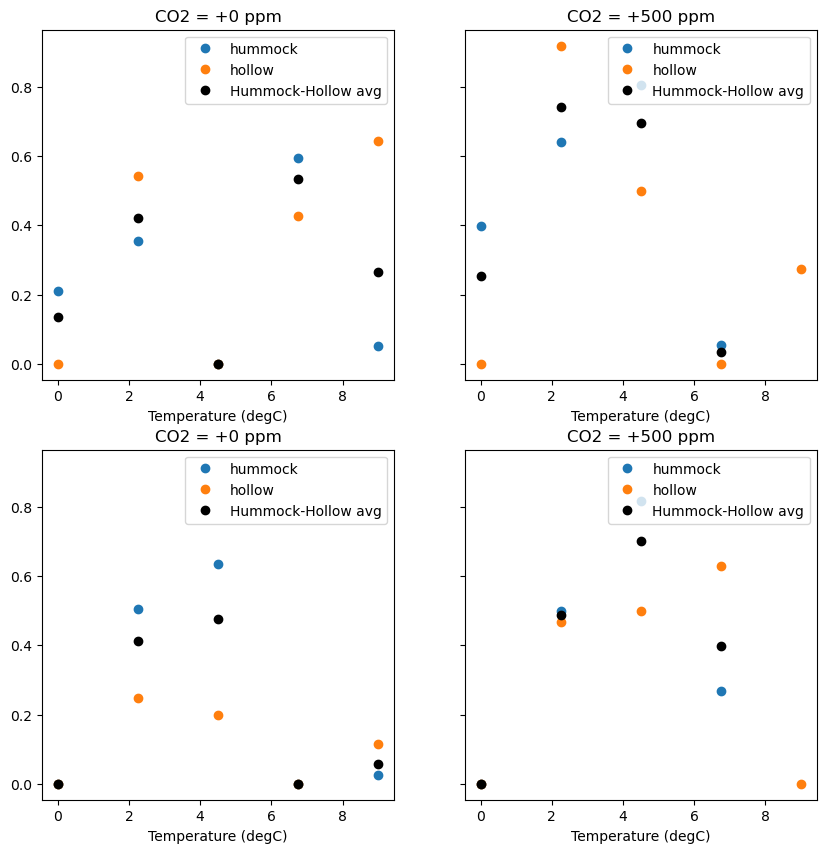

In [9]:
fig, axes = plt.subplots(2, 2, figsize = (10, 10), sharey = True)
for i, co2 in enumerate([0, 500]):
    for j, species in enumerate(['Spruce', 'Larch']):
        ax = axes[j,i]
        for top in ['hummock', 'hollow']:
                ax.plot(obs_frac.loc[(top, species, slice(None), co2)].reset_index()['temperature'], 
                        obs_frac.loc[(top, species, slice(None), co2)].reset_index()['colonization_percent'], 'o', label = top)

        ax.plot(obs_frac_avg.loc[(species, slice(None), co2), :].reset_index()['temperature'],
                obs_frac_avg.loc[(species, slice(None), co2), :].reset_index()['colonization_percent'], 'ok', label = f'Hummock-Hollow avg')

        ax.legend()
        ax.set_title(f'CO2 = +{co2} ppm')
        ax.set_xlabel('Temperature (degC)')